# Multimodal Deepfake Detection — FakeAVCeleb (Kaggle)
**Architecture:** ResNet18-ELA + MesoNet + VGG19 spectrogram + Lightweight AudioCNN → Fusion MLP

## 0 · GPU Check

In [1]:
import subprocess, sys, os
result = subprocess.run(['nvidia-smi','--query-gpu=name,memory.total','--format=csv,noheader'],
                       capture_output=True, text=True)
if result.returncode == 0:
    print('✅ GPU detected:', result.stdout.strip())
else:
    print('⚠️  No GPU — go to Accelerator settings and pick GPU T4')

import torch
print(f'PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


✅ GPU detected: Tesla T4, 15360 MiB
Tesla T4, 15360 MiB
PyTorch 2.10.0+cu128 | CUDA: True
GPU: Tesla T4


## 1 · Installing / Verifying Packages

In [2]:
# On Kaggle most packages are pre-installed; we just need to just ensure versions
import subprocess
subprocess.run(['pip', 'install', '-q', 'albumentations', 'librosa'], check=False)
print('✅ Packages ready')


✅ Packages ready


## 2 · Imports

In [3]:
import torch, torch.nn as nn, torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
import cv2, librosa, numpy as np, pandas as pd, os, json, random
from pathlib import Path
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score,
                             roc_auc_score, confusion_matrix,
                             precision_score, recall_score)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, zipfile, shutil
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Imports done | Device: {DEVICE}')


✅ Imports done | Device: cuda


## 3 · Configuration
> Kaggle writes outputs to `/kaggle/working/` 

In [4]:
class Config:
    # Kaggle uses /kaggle/input (read-only) and /kaggle/working (writable)
    DATASET_PATH    = '/kaggle/input/fakeavceleb'   # updated by download cell
    MODEL_SAVE_PATH = '/kaggle/working/models'
    os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

    MAX_VIDEOS_PER_CLASS = 500  # ~60 min on P100

    BATCH_SIZE    = 4
    NUM_EPOCHS    = 1
    LEARNING_RATE = 1e-4
    IMG_SIZE      = 224
    NUM_FRAMES    = 10
    AUDIO_SR      = 16_000
    AUDIO_DUR_SEC = 2
    DEVICE        = 'cuda' if torch.cuda.is_available() else 'cpu'

config = Config()
print(f'Device         : {config.DEVICE}')
print(f'Max videos/cls : {config.MAX_VIDEOS_PER_CLASS}')
print(f'Output dir     : {config.MODEL_SAVE_PATH}')


Device         : cuda
Max videos/cls : 500
Output dir     : /kaggle/working/models


## 4 · Locating FakeAVCeleb Input

In [5]:
import os
from pathlib import Path

# Check what's available under /kaggle/input
input_root = Path('/kaggle/input/datasets/shreyaty08/fakeavceleb')
print('Contents of /kaggle/input/datasets/shreyaty08/fakeavceleb:')
for p in sorted(input_root.iterdir()):
    print(f'  {p}')

# Auto-detect the FakeAVCeleb folder
candidates = [p for p in input_root.iterdir()
              if 'fakeavceleb' in p.name.lower() or 'fake-av' in p.name.lower()]

if candidates:
    config.DATASET_PATH = str(candidates[0])
    print(f'\n✅ Auto-detected: {config.DATASET_PATH}')
else:
    # Fallback: using the first available input dataset
    all_inputs = list(input_root.iterdir())
    if all_inputs:
        config.DATASET_PATH = str(all_inputs[0])
        print(f'\n⚠️  FakeAVCeleb not found. Using: {config.DATASET_PATH}')
        print('Add the dataset via + Add Data and re-run.')
    else:
        print('\n❌ No input datasets found. Add FakeAVCeleb via + Add Data.')

print(f'\nDataset path: {config.DATASET_PATH}')


Contents of /kaggle/input/datasets/shreyaty08/fakeavceleb:
  /kaggle/input/datasets/shreyaty08/fakeavceleb/FakeAVCeleb_v1.2

✅ Auto-detected: /kaggle/input/datasets/shreyaty08/fakeavceleb/FakeAVCeleb_v1.2

Dataset path: /kaggle/input/datasets/shreyaty08/fakeavceleb/FakeAVCeleb_v1.2


## 5 · Discover & Subsample Dataset

In [6]:
REAL_DIRS = {'RealVideo-RealAudio'}
FAKE_DIRS = {'FakeVideo-FakeAudio', 'FakeVideo-RealAudio', 'RealVideo-FakeAudio'}

def discover_fakeavceleb(root):
    records = []
    root = Path(root)

    # Searching at ANY depth for the known category folder names
    for dirpath in root.rglob('*'):
        if dirpath.is_dir() and dirpath.name in (REAL_DIRS | FAKE_DIRS):
            label = 0 if dirpath.name in REAL_DIRS else 1
            for vf in dirpath.rglob('*.mp4'):
                records.append({'video_path': str(vf), 'label': label})

    # Fallback: CSV metadata
    if not records:
        for csv_f in root.rglob('*.csv'):
            try:
                tmp = pd.read_csv(csv_f)
                path_col  = next((c for c in tmp.columns if 'path' in c.lower()), None)
                label_col = next((c for c in tmp.columns
                                  if c.lower() in ('label','class','fake','real','type')), None)
                if path_col and label_col:
                    for _, row in tmp.iterrows():
                        vp = str(row[path_col])
                        if not os.path.isabs(vp):
                            vp = str(root / vp)
                        lbl = 1 if str(row[label_col]).lower() in ('fake','1','deepfake') else 0
                        if os.path.exists(vp):
                            records.append({'video_path': vp, 'label': lbl})
                    if records:
                        break
            except Exception:
                pass

    # Last resort: print tree so we can see what's there
    if not records:
        print('❌ No videos found. Directory tree:')
        for p in sorted(root.rglob('*'))[:60]:
            if p.is_dir(): print(' ', p)
        raise FileNotFoundError(f'No .mp4 files found under {root}')

    return pd.DataFrame(records)


print('Scanning FakeAVCeleb directory …')
full_df = discover_fakeavceleb(config.DATASET_PATH)

real_n = (full_df['label'] == 0).sum()
fake_n = (full_df['label'] == 1).sum()
print(f'\nFound {len(full_df):,} videos total')
print(f'  Real  : {real_n:,}')
print(f'  Fake  : {fake_n:,}')

if fake_n == 0:
    print('\n⚠️  Still 0 fake — all dirs under root:')
    for d in sorted(Path(config.DATASET_PATH).rglob('*')):
        if d.is_dir(): print(' ', d)
else:
    print('\n✅ Dataset discovered successfully')

Scanning FakeAVCeleb directory …

Found 21,560 videos total
  Real  : 500
  Fake  : 21,060

✅ Dataset discovered successfully


In [7]:
def balanced_subsample(df, n_per_class, seed=SEED):
    """Randomly pick n_per_class from each label."""
    rng = np.random.default_rng(seed)
    parts = []
    for lbl in [0, 1]:
        sub = df[df['label'] == lbl]
        k = min(n_per_class, len(sub))
        idx = rng.choice(len(sub), size=k, replace=False)
        parts.append(sub.iloc[idx])
    return pd.concat(parts).sample(frac=1, random_state=seed).reset_index(drop=True)


subset_df = balanced_subsample(full_df, config.MAX_VIDEOS_PER_CLASS)
train_df, val_df = train_test_split(subset_df, test_size=0.2,
                                    stratify=subset_df['label'],
                                    random_state=SEED)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f'Subset  : {len(subset_df):,} videos  ({config.MAX_VIDEOS_PER_CLASS} per class)')
print(f'Train   : {len(train_df):,}  (real {(train_df.label==0).sum()}, fake {(train_df.label==1).sum()})')
print(f'Val     : {len(val_df):,}  (real {(val_df.label==0).sum()}, fake {(val_df.label==1).sum()})')


Subset  : 1,000 videos  (500 per class)
Train   : 800  (real 400, fake 400)
Val     : 200  (real 100, fake 100)


## 6 · Dataset Class

In [8]:
class FakeAVCelebDataset(Dataset):
    """
    Reads real MP4 files from FakeAVCeleb.
    Each sample returns:
      - frames  : Tensor [NUM_FRAMES, 3, IMG_SIZE, IMG_SIZE]
      - audio   : Tensor [3, IMG_SIZE, IMG_SIZE]  (mel-spectrogram)
      - label   : float  0=real / 1=fake
    """
    def __init__(self, dataframe, mode='train'):
        self.df   = dataframe.reset_index(drop=True)
        self.mode = mode

        if mode == 'train':
            self.transform = A.Compose([
                A.RandomResizedCrop(size=(config.IMG_SIZE, config.IMG_SIZE), scale=(0.8, 1.0)),
                A.HorizontalFlip(p=0.5),
                A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, p=0.5),
                A.GaussNoise(p=0.2),
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2()
            ])
        else:
            self.transform = A.Compose([
                A.Resize(height=config.IMG_SIZE, width=config.IMG_SIZE),
                A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
                ToTensorV2()
            ])

    def __len__(self): return len(self.df)

    # ── Video loading ─────────────────────────────────────────────────────────
    def _load_frames(self, path):
        cap = cv2.VideoCapture(path)
        if not cap.isOpened():
            return torch.zeros(config.NUM_FRAMES, 3, config.IMG_SIZE, config.IMG_SIZE)

        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 1
        indices = set(np.linspace(0, total - 1, config.NUM_FRAMES, dtype=int))
        frames, fi = [], 0

        while True:
            ret, frame = cap.read()
            if not ret: break
            if fi in indices:
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                aug   = self.transform(image=frame)['image']
                frames.append(aug)
            fi += 1
        cap.release()

        # pad if fewer frames than expected
        while len(frames) < config.NUM_FRAMES:
            frames.append(frames[-1] if frames else torch.zeros(3, config.IMG_SIZE, config.IMG_SIZE))
        return torch.stack(frames[:config.NUM_FRAMES])

    # ── Audio loading ─────────────────────────────────────────────────────────
    def _load_audio_spec(self, path):
        try:
            target_len = config.AUDIO_SR * config.AUDIO_DUR_SEC
            audio, sr  = librosa.load(path, sr=config.AUDIO_SR, mono=True, duration=config.AUDIO_DUR_SEC)
            if len(audio) < target_len:
                audio = np.pad(audio, (0, target_len - len(audio)))

            mel  = librosa.feature.melspectrogram(y=audio, sr=config.AUDIO_SR,
                                                  n_mels=128, n_fft=2048, hop_length=512)
            mdb  = librosa.power_to_db(mel, ref=np.max)
            mdb  = cv2.resize(mdb, (config.IMG_SIZE, config.IMG_SIZE))
            mdb3 = np.stack([mdb, mdb, mdb]).astype(np.float32)
            mdb3 = (mdb3 - mdb3.mean()) / (mdb3.std() + 1e-8)
            return torch.FloatTensor(mdb3)
        except Exception:
            return torch.zeros(3, config.IMG_SIZE, config.IMG_SIZE)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        path   = row['video_path']
        frames = self._load_frames(path)
        audio  = self._load_audio_spec(path)
        label  = torch.tensor(row['label'], dtype=torch.float32)
        return {'frames': frames, 'audio': audio, 'label': label}


# ── Sanity check on one sample ────────────────────────────────────────────────
if len(train_df) > 0:
    tmp_ds = FakeAVCelebDataset(train_df.head(2), mode='val')
    sample = tmp_ds[0]
    print(f'frames shape : {sample["frames"].shape}')
    print(f'audio  shape : {sample["audio"].shape}')
    print(f'label        : {sample["label"]}')
    print('✅ Dataset class OK')


frames shape : torch.Size([10, 3, 224, 224])
audio  shape : torch.Size([3, 224, 224])
label        : 1.0
✅ Dataset class OK


## 7 · DataLoaders

In [9]:
train_dataset = FakeAVCelebDataset(train_df, mode='train')
val_dataset   = FakeAVCelebDataset(val_df,   mode='val')

train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=config.BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f'Train : {len(train_dataset):,} samples  ({len(train_loader)} batches)')
print(f'Val   : {len(val_dataset):,} samples  ({len(val_loader)} batches)')


Train : 800 samples  (200 batches)
Val   : 200 samples  (50 batches)


## 8 · Model Architecture

In [10]:
# ─── Exact same model architecture as the original notebook ────────────────
class ResNet18ELA(nn.Module):
    def __init__(self, embedding_dim=512, pretrained=True):
        super().__init__()
        backbone = models.resnet18(weights='IMAGENET1K_V1' if pretrained else None)
        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-1])
        self.embedding_head = nn.Sequential(
            nn.Flatten(), nn.Linear(512, 256), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(256, embedding_dim), nn.LayerNorm(embedding_dim))
    def forward(self, frames):
        B, T, C, H, W = frames.shape
        embs = [self.embedding_head(self.feature_extractor(frames[:, t]).view(B, -1)) for t in range(T)]
        return nn.functional.normalize(torch.stack(embs, 1).mean(1), p=2, dim=1)

class MesoNet(nn.Module):
    def __init__(self, embedding_dim=128):
        super().__init__()
        def blk(ci, co, k, p): return nn.Sequential(
            nn.Conv2d(ci, co, k, padding=p), nn.BatchNorm2d(co), nn.ReLU(), nn.MaxPool2d(2))
        self.conv1, self.conv2 = blk(3,8,3,1), blk(8,8,5,2)
        self.conv3 = blk(8,16,5,2)
        self.conv4 = nn.Sequential(nn.Conv2d(16,16,5,padding=2), nn.BatchNorm2d(16),
                                   nn.ReLU(), nn.MaxPool2d(4))
        self.head = nn.Sequential(nn.Flatten(), nn.Linear(16*7*7, 256), nn.ReLU(),
                                  nn.Dropout(0.3), nn.Linear(256, embedding_dim), nn.LayerNorm(embedding_dim))
    def forward(self, frames):
        B, T, C, H, W = frames.shape
        embs = []
        for t in range(T):
            x = self.conv4(self.conv3(self.conv2(self.conv1(frames[:, t]))))
            embs.append(self.head(x))
        return nn.functional.normalize(torch.stack(embs, 1).mean(1), p=2, dim=1)

class VGG19Spectrogram(nn.Module):
    def __init__(self, embedding_dim=4096, pretrained=True):
        super().__init__()
        vgg = models.vgg19(weights='IMAGENET1K_V1' if pretrained else None)
        self.features, self.avgpool = vgg.features, vgg.avgpool
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(512*7*7, 4096), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(4096, 4096), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(4096, embedding_dim), nn.LayerNorm(embedding_dim))
    def forward(self, x):
        return nn.functional.normalize(self.classifier(self.avgpool(self.features(x))), p=2, dim=1)

class LightweightAudioCNN(nn.Module):
    def __init__(self, embedding_dim=128):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.AdaptiveAvgPool2d((4,4)))
        self.head = nn.Sequential(nn.Flatten(), nn.Linear(128*4*4, 256), nn.ReLU(),
                                  nn.Dropout(0.3), nn.Linear(256, embedding_dim), nn.LayerNorm(embedding_dim))
    def forward(self, x):
        return nn.functional.normalize(self.head(self.conv_layers(x)), p=2, dim=1)

class MultimodalFusion(nn.Module):
    def __init__(self, input_dim=4864, hidden_dims=[1024, 256]):
        super().__init__()
        layers, prev = [], input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(0.3)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.mlp, self.sigmoid = nn.Sequential(*layers), nn.Sigmoid()
    def forward(self, embs):
        fused = torch.cat(embs, dim=1)
        return self.sigmoid(self.mlp(fused)), self.mlp(fused)

class CompleteMultimodalModel(nn.Module):
    def __init__(self, modality_dropout=0.15):
        super().__init__()
        print('Initializing model …')
        self.visual_ela  = ResNet18ELA(512)
        self.visual_meso = MesoNet(128)
        self.audio_vgg   = VGG19Spectrogram(4096)
        self.audio_cnn   = LightweightAudioCNN(128)
        self.fusion      = MultimodalFusion(512+128+4096+128)
        self.modality_dropout = modality_dropout

        # ── Freeze VGG19 — 138M params, too heavy for small datasets ──
        for param in self.audio_vgg.parameters():
            param.requires_grad = False

        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in self.parameters())
        print(f'✅ Model ready | total={total:,} | trainable={trainable:,}')

    def forward(self, batch, training=True):
        ela  = self.visual_ela(batch['ela_frames'])
        meso = self.visual_meso(batch['rgb_frames'])
        vgg  = self.audio_vgg(batch['audio_features'])
        cnn  = self.audio_cnn(batch['audio_features'])
        if training and self.modality_dropout > 0:
            for emb in [ela, meso, vgg, cnn]:
                if torch.rand(1).item() < self.modality_dropout:
                    emb.zero_()
        return self.fusion([ela, meso, vgg, cnn])

# Quick shape test
_m = CompleteMultimodalModel()
_b = {'ela_frames': torch.randn(2,10,3,224,224),
      'rgb_frames': torch.randn(2,10,3,224,224),
      'audio_features': torch.randn(2,3,224,224)}
with torch.no_grad():
    _p, _l = _m(_b, training=False)
print(f'Probs shape: {_p.shape}  Logits shape: {_l.shape}')
del _m, _b, _p, _l


Initializing model …
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 176MB/s] 


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:03<00:00, 187MB/s]  


✅ Model ready | total=173,944,233 | trainable=17,584,489
Probs shape: torch.Size([2, 1])  Logits shape: torch.Size([2, 1])


In [11]:
RESUME_FROM = None  # set to e.g. '/kaggle/working/models/checkpoint_epoch_2.pth' 

start_epoch = 0
if RESUME_FROM and os.path.exists(RESUME_FROM):
    ckpt = torch.load(RESUME_FROM, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    history      = ckpt['history']
    best_val_acc = ckpt['best_val_acc']
    start_epoch  = ckpt['epoch'] + 1
    print(f'✅ Resumed from epoch {start_epoch}')
else:
    print('Starting fresh')

Starting fresh


In [12]:
import time, threading

def keep_alive():
    while True:
        time.sleep(240)
        print('.', end='', flush=True)

thread = threading.Thread(target=keep_alive, daemon=True)
thread.start()
print('Keep-alive started ✅')

Keep-alive started ✅


## 9 · Training

In [13]:
print('='*70)
print('🚀 STARTING TRAINING ON FakeAVCeleb')
print('='*70)

model     = CompleteMultimodalModel(modality_dropout=0.15).to(DEVICE)
optimizer = AdamW(model.parameters(), lr=config.LEARNING_RATE)
criterion = nn.BCELoss()

history   = {'train_loss':[], 'train_acc':[], 'train_f1':[],
             'val_loss':[],   'val_acc':[],   'val_f1':[], 'val_auc':[]}
best_val_acc = 0.0

for epoch in range(start_epoch, config.NUM_EPOCHS):
    print(f'\n--- Epoch {epoch+1}/{config.NUM_EPOCHS} ---')

    # ── Train ────────────────────────────────────────────────────────────────
    model.train()
    t_loss, t_pred, t_true = 0, [], []
    for batch in tqdm(train_loader, desc='Train'):
        frames = batch['frames'].to(DEVICE)
        audio  = batch['audio'].to(DEVICE)
        labels = batch['label'].to(DEVICE)

        mb = {'rgb_frames': frames, 'ela_frames': frames, 'audio_features': audio}
        probs, _ = model(mb, training=True)

        loss = criterion(probs.squeeze(), labels)
        optimizer.zero_grad(); loss.backward(); optimizer.step()

        t_loss += loss.item()
        t_pred.extend((probs.squeeze() > 0.5).float().cpu().numpy())
        t_true.extend(labels.cpu().numpy())

    tl = t_loss / len(train_loader)
    ta = accuracy_score(t_true, t_pred)
    tf = f1_score(t_true, t_pred, zero_division=0)

    # ── Validate ─────────────────────────────────────────────────────────────
    model.eval()
    v_loss, v_pred, v_true, v_prob = 0, [], [], []
    with torch.no_grad():
        for batch in tqdm(val_loader, desc='Val  '):
            frames = batch['frames'].to(DEVICE)
            audio  = batch['audio'].to(DEVICE)
            labels = batch['label'].to(DEVICE)

            mb = {'rgb_frames': frames, 'ela_frames': frames, 'audio_features': audio}
            probs, _ = model(mb, training=False)

            v_loss += criterion(probs.squeeze(), labels).item()
            v_pred.extend((probs.squeeze() > 0.5).float().cpu().numpy())
            v_true.extend(labels.cpu().numpy())
            v_prob.extend(probs.squeeze().cpu().numpy())

    vl = v_loss / len(val_loader)
    va = accuracy_score(v_true, v_pred)
    vf = f1_score(v_true, v_pred, zero_division=0)
    try: vauc = roc_auc_score(v_true, v_prob)
    except: vauc = 0.0

    # Record
    for k, v in [('train_loss',tl),('train_acc',ta),('train_f1',tf),
                 ('val_loss',vl),('val_acc',va),('val_f1',vf),('val_auc',vauc)]:
        history[k].append(v)

    print(f'  Train  loss={tl:.4f}  acc={ta:.4f}  f1={tf:.4f}')
    print(f'  Val    loss={vl:.4f}  acc={va:.4f}  f1={vf:.4f}  auc={vauc:.4f}')

    if va > best_val_acc:
        best_val_acc = va
        torch.save(model.state_dict(), f'{config.MODEL_SAVE_PATH}/best_model.pth')
        print(f'  💾 Best model saved (acc={va:.4f})')

print(f'\n🏆 Best Val Accuracy: {best_val_acc:.4f}')

# Saving checkpoint every epoch so we can resume if cut off
torch.save({
    'epoch'     : epoch,
    'model_state_dict'     : model.state_dict(),
    'optimizer_state_dict' : optimizer.state_dict(),
    'history'   : history,
    'best_val_acc' : best_val_acc,
}, f'{config.MODEL_SAVE_PATH}/checkpoint_epoch_{epoch+1}.pth')
print(f'  📌 Checkpoint saved (epoch {epoch+1})')


🚀 STARTING TRAINING ON FakeAVCeleb
Initializing model …
✅ Model ready | total=173,944,233 | trainable=17,584,489

--- Epoch 1/1 ---


Val  : 100%|██████████| 50/50 [00:30<00:00,  1.62it/s]


  Train  loss=0.6214  acc=0.6388  f1=0.6392
  Val    loss=0.3435  acc=0.8600  f1=0.8727  auc=0.9456
  💾 Best model saved (acc=0.8600)

🏆 Best Val Accuracy: 0.8600
  📌 Checkpoint saved (epoch 1)


## 10 · Results & Plots

        VALIDATION RESULTS
  Accuracy    : 0.8600  (86.00%)
  F1 Score    : 0.8727
  Precision   : 0.8000
  Recall      : 0.9600
  Specificity : 0.7600
  AUC-ROC     : 0.9456

              precision    recall  f1-score   support

        Real       0.95      0.76      0.84       100
        Fake       0.80      0.96      0.87       100

    accuracy                           0.86       200
   macro avg       0.88      0.86      0.86       200
weighted avg       0.88      0.86      0.86       200



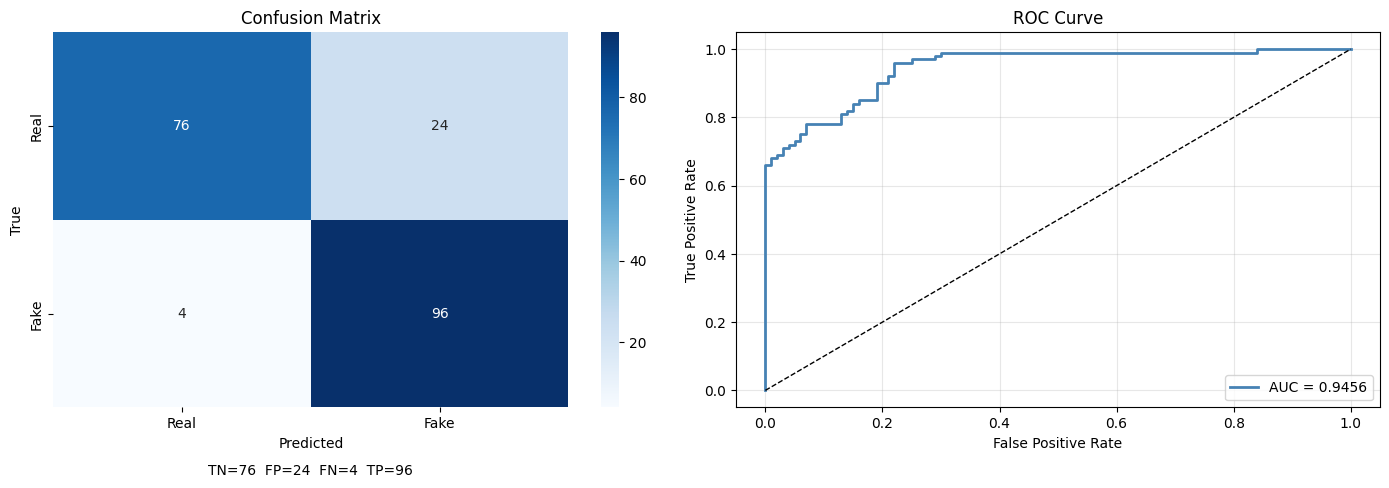

Saved → /kaggle/working/models/results.png


In [14]:
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score, confusion_matrix,
                             classification_report)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── Collecting all predictions on validation set ─────────────────────────────────
model.eval()
all_preds, all_true, all_probs = [], [], []

with torch.no_grad():
    for batch in val_loader:
        frames = batch['frames'].to(DEVICE)
        audio  = batch['audio'].to(DEVICE)
        labels = batch['label']

        mb = {
            'rgb_frames'     : frames,
            'ela_frames'     : frames,
            'audio_features' : audio
        }
        probs, _ = model(mb, training=False)
        preds    = (probs.squeeze() > 0.5).float().cpu()

        all_preds.extend(preds.numpy())
        all_true.extend(labels.numpy())
        all_probs.extend(probs.squeeze().cpu().numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)
all_probs = np.array(all_probs)

# ── Metrics ───────────────────────────────────────────────────────────────────
acc       = accuracy_score(all_true, all_preds)
f1        = f1_score(all_true, all_preds, zero_division=0)
precision = precision_score(all_true, all_preds, zero_division=0)
recall    = recall_score(all_true, all_preds, zero_division=0)
auc       = roc_auc_score(all_true, all_probs)
specificity = recall_score(all_true, all_preds, pos_label=0, zero_division=0)  # true negative rate

print('='*45)
print('        VALIDATION RESULTS')
print('='*45)
print(f'  Accuracy    : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  F1 Score    : {f1:.4f}')
print(f'  Precision   : {precision:.4f}')
print(f'  Recall      : {recall:.4f}')
print(f'  Specificity : {specificity:.4f}')
print(f'  AUC-ROC     : {auc:.4f}')
print('='*45)
print()
print(classification_report(all_true, all_preds, target_names=['Real', 'Fake']))

# ── Confusion Matrix ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: confusion matrix
cm = confusion_matrix(all_true, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'],
            ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix')

# Annotate TN/FP/FN/TP
tn, fp, fn, tp = cm.ravel()
axes[0].text(0.5, -0.18,
    f'TN={tn}  FP={fp}  FN={fn}  TP={tp}',
    ha='center', transform=axes[0].transAxes, fontsize=10)

# Right: ROC curve
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(all_true, all_probs)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{config.MODEL_SAVE_PATH}/results.png', dpi=100)
plt.show()
print(f'Saved → {config.MODEL_SAVE_PATH}/results.png')

## 11 · Save Model


In [ ]:
# Loading best weights, save + zip
model.load_state_dict(torch.load(f'{config.MODEL_SAVE_PATH}/best_model.pth',
                                  map_location='cpu'))
torch.save(model.state_dict(), f'{config.MODEL_SAVE_PATH}/final_model.pth')

with open(f'{config.MODEL_SAVE_PATH}/training_history.json', 'w') as f:
    json.dump(history, f, indent=2)

# Zip everything
zip_path = '/content/multimodal_deepfake_model.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fp in Path(config.MODEL_SAVE_PATH).rglob('*'):
        zf.write(fp, arcname=fp.relative_to(config.MODEL_SAVE_PATH))

size_mb = Path(zip_path).stat().st_size / 1e6
print(f'\n📦 Zipped to {zip_path}  ({size_mb:.1f} MB)')


.